# nD DDPMS(Denoise Diffusion Probabilistic Models) Exemple

Le processus de diffusion est de meme que pour la version 1D seulement ici x est un tenseur correspondant a l'image considerée.
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_t|\sqrt{1-\beta_t} \, x_{t-1};\beta_t \textbf{I}) $$
Ou la moyenne et la variances sont choisi de tel sorte que la sortie de la distribution pour $x_T$ ai une moyenne nulle et une variance unitaire. Et $\beta$ est la quantité de bruit ajouté a chaque étape.

**Propriété:** Une distribution gaussienne peut etre échantilloné en ajoutant au vecteur moyen un vecteur avec une distribution bruitée normalisé sur l'écart type. Ce qui donne, 
$$ q(x_t | x_{t-1}) := \sqrt{1-\beta_t}x_{t-1}+\sqrt{\beta_t \epsilon} $$

Pour l'étape d'avant cela devient, 

$$ q(x_t | x_{t-2}) := \sqrt{1-\beta_t}\boxed{[\sqrt{1-\beta_t-1}x_{t-2}+\sqrt{\beta_{t-1}\epsilon}]}+\sqrt{\beta_t \epsilon} \quad où \quad \boxed{\sqrt{1-\beta_t-1}x_{t-2}+\sqrt{\beta_{t-1}\epsilon}} = q(x_t{-1} | x_{t-2})$$


Si on déroule le calcule jusqu'a $x_0$ en posant $\alpha_t := 1-\beta_t$ d'ou $\bar{\alpha}:= \prod_{s=1}^{t}\alpha_s$ on obtient,
$$ q(x_t | x_0) := \mathcal{N}(x_t|\sqrt{\bar{\alpha}}x_0 ; (1-\alpha_t)\textbf{I}) $$

On montre ainsi que peut importe le nombre d'étape de bruitage on pourras toujours revenir il existe toujours un chemin entre l'image bruité et l'originale.


---
Pour le processus de propagation arriere (backawar), on sait que le modele doit aussi fonctionner comme une distribution gaussienne, de faite la prediction de la moyenne et de l'ecart type sachant une image bruité suffis.

$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}|\mu(x_t,t);\sigma_t^2\textbf{I})  $$

ici on peut montrer que la moyenne optimale s'ecrit comme, 

$$\frac{1}{\sqrt{\alpha_t}}(x_t-\frac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon) \quad d'ou \quad \mu(x_t,t)=\frac{1}{\sqrt{\alpha_t}}(x_t-\frac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_\theta(x_t,t))$$

Sachant cela on peut écrir une fonction de perte (loss) comme une Mean-Square-Error (MSE) mise a l'échel entre le vrai bruit ajouté et celui prédit par le modele. De sorte que, 

$$ \mathcal{L_t} = \mathbb{E}_{x_0,\epsilon}\left[\frac{\beta_t^2}{2\sigma_t^2\alpha_t(1-\bar{\alpha_t})} ||\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha{t}}}x_0+\sqrt{1-\bar{\alpha_t}}\epsilon,t )||^2 \right]


In [18]:
# Import of libraries
import random
import imageio
import numpy as np
from argparse import ArgumentParser

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import einops
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchview import draw_graph

from torchvision.transforms import Compose, ToTensor, Lambda
from torchvision.datasets.mnist import MNIST, FashionMNIST

# Setting reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Definitions
STORE_PATH_MNIST = f"ddpm_model_mnist.pt"
STORE_PATH_FASHION = f"ddpm_model_fashion.pt"

In [2]:
def get_best_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


class ImageVisualizer:
    def __init__(self, figsize=(8, 8), cmap="gray"):
        self.figsize = figsize
        self.cmap = cmap

    def _to_numpy(self, images):
        """Convertit en numpy si nécessaire"""
        if isinstance(images, torch.Tensor):
            return images.detach().cpu().numpy()
        return images

    def show_images(self, images, title=""):
        """Affiche les images en grille carrée"""
        images = self._to_numpy(images)

        fig = plt.figure(figsize=self.figsize)

        rows = int(len(images) ** 0.5)
        cols = round(len(images) / rows)

        idx = 0
        for r in range(rows):
            for c in range(cols):
                fig.add_subplot(rows, cols, idx + 1)

                if idx < len(images):
                    plt.imshow(images[idx][0], cmap=self.cmap)
                    plt.axis("off")
                    idx += 1

        fig.suptitle(title, fontsize=20)
        plt.show()

    def show_first_batch(self, loader):
        """Affiche le premier batch"""
        for batch in loader:
            self.show_images(batch[0], "Images in the first batch")
            break


    # def show_forward(self, ddpm, loader, device):
    #     """Affiche le processus de bruitage (forward)"""
    #     for batch in loader:
    #         imgs = batch[0]

    #         self.show_images(imgs, "Original images")

    #         for percent in [0.25, 0.5, 0.75, 1]:
    #             noisy_imgs = ddpm(
    #                 imgs.to(device),
    #                 [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))]
    #             )

    #             self.show_images(
    #                 noisy_imgs,
    #                 f"DDPM Noisy images {int(percent * 100)}%"
    #             )
    #         break


    def show_forward(self, ddpm, loader, device):
        """Affiche le processus de bruitage (forward) en une figure unique."""
        import matplotlib.pyplot as plt
        import matplotlib.gridspec as gridspec
        import torchvision.utils as vutils
        import numpy as np

        percentages = [0, 0.25, 0.5, 0.75, 1.0]
        labels = ["t = 0\n(original)", "t = 25%", "t = 50%", "t = 75%", "t = 100%"]
        
        for batch in loader:
            imgs = batch[0]
            n_cols = min(len(imgs), 8)  # max 8 images par ligne

            # Collecter les blocs d'images
            blocks = []
            # Images originales
            blocks.append(imgs[:n_cols])
            # Images bruitées
            for percent in percentages[1:]:
                noisy = ddpm(
                    imgs.to(device),
                    [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))]
                )
                blocks.append(noisy[:n_cols].cpu())

            # --- Figure ---
            n_rows = len(percentages)
            fig, axes = plt.subplots(
                n_rows, n_cols,
                figsize=(n_cols * 1.4, n_rows * 1.4),
                gridspec_kw={"hspace": 0.08, "wspace": 0.04}
            )

            for row_idx, (block, label) in enumerate(zip(blocks, labels)):
                for col_idx in range(n_cols):
                    ax = axes[row_idx, col_idx]
                    img = block[col_idx].detach().cpu()

                    # Normalisation [0,1] pour l'affichage
                    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                    img_np = img.permute(1, 2, 0).numpy() if img.ndim == 3 else img.numpy()

                    # Niveaux de gris ou couleur
                    if img_np.shape[-1] == 1:
                        ax.imshow(img_np.squeeze(), cmap="gray", vmin=0, vmax=1)
                    else:
                        ax.imshow(np.clip(img_np, 0, 1))

                    ax.axis("off")

                    # Étiquette de ligne sur la première colonne uniquement
                    if col_idx == 0:
                        ax.annotate(
                            label,
                            xy=(0, 0.5),
                            xycoords="axes fraction",
                            xytext=(-8, 0),
                            textcoords="offset points",
                            fontsize=7.5,
                            fontfamily="serif",
                            ha="right",
                            va="center",
                            rotation=45,
                            annotation_clip=False
                        )
            # Titre général
            fig.suptitle(
                "DDPM — Forward diffusion process",
                fontsize=10,
                fontfamily="serif",
                y=1.01
            )

            # plt.savefig(
            #     "ddpm_forward.pdf",
            #     bbox_inches="tight",
            #     dpi=300,
            #     format="pdf"
            # )
            plt.show()
            break

    def show_backward(self, ddpm, device, n_samples=8):
        percentages = [1.0, 0.75, 0.5, 0.25, 0]
        labels = ["t = 100%\n(bruit)", "t = 75%", "t = 50%", "t = 25%", "t = 0\n(généré)"]

        # On génère pas à pas et on snapshote aux % voulus
        c, h, w = ddpm.image_chw
        x = torch.randn(n_samples, c, h, w).to(device)
        snap_steps = {int(p * ddpm.n_steps): p for p in percentages}
        blocks = {1.0: x.cpu()}  # snapshot initial

        with torch.no_grad():
            for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
                time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
                eta_theta = ddpm.backward(x, time_tensor)
                alpha_t, alpha_t_bar = ddpm.alphas[t], ddpm.alpha_bars[t]
                x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)
                if t > 0:
                    x = x + ddpm.betas[t].sqrt() * torch.randn_like(x)
                step_pct = t / ddpm.n_steps
                for p in [0.75, 0.5, 0.25]:
                    if step_pct <= p and p not in blocks:
                        blocks[p] = x.cpu()
            blocks[0] = x.cpu()

        fig, axes = plt.subplots(len(percentages), n_samples, figsize=(n_samples * 1.4, len(percentages) * 1.4),
                                gridspec_kw={"hspace": 0.08, "wspace": 0.04})
        for row_idx, p in enumerate(percentages):
            block = blocks[p]
            for col_idx in range(n_samples):
                ax = axes[row_idx, col_idx]
                img = block[col_idx]
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                ax.imshow(img.squeeze(), cmap="gray")
                ax.axis("off")
                if col_idx == 0:
                    ax.annotate(labels[row_idx], xy=(0, 0.5), xycoords="axes fraction",
                                xytext=(-8, 0), textcoords="offset points",
                                fontsize=7.5, ha="right", va="center", rotation=45, annotation_clip=False)
        fig.suptitle("DDPM — Backward diffusion process", fontsize=10, y=1.01)
        plt.show()

# Settings

In [3]:
no_train = True

device = get_best_device()
print(device)
viz = ImageVisualizer()

no_train = False
fashion = True
batch_size = 128
n_epochs = 20
lr = 0.001
store_path = "models/ddpm_mnist.pt"

cpu


# Choix du Dataset

In [4]:
# Loading the data (converting each image into a tensor and normalizing between [-1, 1])
transform = Compose([
    ToTensor(),
    Lambda(lambda x: (x - 0.5) * 2)]
)
ds_fn = MNIST # FashionMNIST peut etre tester aussi
dataset = ds_fn("./datasets", download=True, train=True, transform=transform)
loader = DataLoader(dataset, batch_size, shuffle=True)

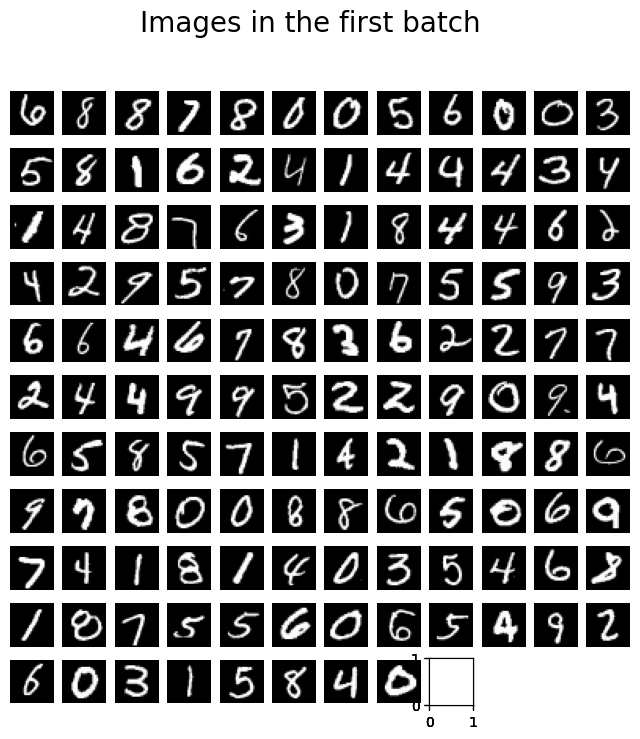

In [5]:
viz.show_first_batch(loader)

# Modele du DDPM

On créé le modele qui va contenir les betas et alphas et lancer le processus avant (foward). Pour le processus arriere (backward) le modele va simplement utiliser le reseau de neuronne de reconstruction.

In [6]:
class MyDDPM(nn.Module):

    def __init__(self, network, n_steps=200, min_beta=10 ** -4, max_beta=0.02, device=None, image_chw=(1, 28, 28)):
        super(MyDDPM, self).__init__()
        self.n_steps = n_steps              # Nombre total d'étapes de diffusion (plus il est grand, plus la diffusion est fine)
        self.device = device
        self.image_chw = image_chw          # Format des images (channels, height, width)
        self.network = network.to(device)   # Réseau de neurones qui va apprendre à prédire le bruit

        # Création d'une séquence de betas (variance du bruit ajouté à chaque étape)
        # On interpole linéairement entre min_beta et max_beta
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(device)
        
        self.alphas = 1 - self.betas        # alpha = 1 - beta (quantité d'information conservée à chaque étape)

        # alpha_bar = produit cumulatif des alphas
        # Cela représente combien de signal original reste après t étapes
        self.alpha_bars = torch.tensor(
            [torch.prod(self.alphas[:i + 1]) for i in range(len(self.alphas))]
        ).to(device)

    def forward(self, x0, t, eta=None):
        """
        Forward process (diffusion):
        On ajoute du bruit à une image propre x0 jusqu'à un temps t donné.

        x0 : image originale
        t : timestep (peut être un batch de valeurs)
        eta : bruit (si None, généré aléatoirement)
        """

        n, c, h, w = x0.shape           # Dimensions du batch
        a_bar = self.alpha_bars[t]      # Récupère alpha_bar pour chaque t

        # Si aucun bruit n'est fourni, on génère du bruit gaussien
        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)

        # Formule clé du DDPM :
        # x_t = sqrt(alpha_bar) * x0 + sqrt(1 - alpha_bar) * bruit
        noisy = (
            a_bar.sqrt().reshape(n, 1, 1, 1) * x0
            + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        )

        return noisy

    def backward(self, x, t):
        """
        Reverse process (débruitage):
        Le réseau essaie de prédire le bruit présent dans l'image x au temps t.

        x : image bruitée
        t : timestep

        Retour :
        estimation du bruit
        """
        return self.network(x, t)

Pour la generation des images on commences par avec un bruit aléatoire et itére pour $t\in[0,T]$. A chaque étapes on estime le bruit avec `eta_theta` et on applique la fonction de débruitage. Enfin, un bruit supplémentaire et ajouté comme une dynamique de Langevin. 

In [7]:
def generate_new_images(ddpm, n_samples=16, device=None, c=1, h=28, w=28):
    with torch.no_grad():
        if device is None:
            device = ddpm.device

        x = torch.randn(n_samples, c, h, w).to(device)

        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)

            if t > 0:
                beta_t = ddpm.betas[t]
                x = x + beta_t.sqrt() * torch.randn(n_samples, c, h, w).to(device)

    return x

# Réseau de Neuronnes

A titre d'éxemple ici on utilise un modele U-Net. On commence par la création d'un bloque qui va garder la dimension spatiale inchangé. Ce bloque sera utilisé dans tous les niveau du U-Net

In [8]:
class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(MyBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out

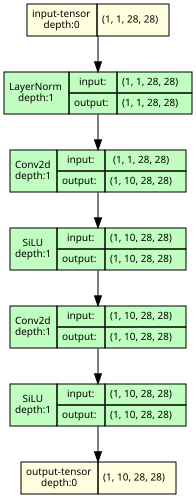

In [19]:
block = MyBlock(shape=(1, 28, 28), in_c=1, out_c=10)

model_graph = draw_graph(
    block,
    input_size=(1, 1, 28, 28),  # (batch, C, H, W)
    device='meta'               # pas de mémoire allouée
)
model_graph.visual_graph        # affiche dans Jupyter

**Remarque:** Le modele image-vers-image a besoins d'etre conditionner pour le pas de temps courant dans un DDPM.
Pour ce faire en pratique on utilsie a embeding sinusoidale et un MLPs avec une seule couche. Le tenseur résultant est ajouté chanel par chanel comme une entrée du réseau a chaque niveau du U-Net. 


In [9]:
def sinusoidal_embedding(n, d):
    # Returns the standard positional embedding
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)])
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    embedding[:,::2] = torch.sin(t * wk[:,::2])
    embedding[:,1::2] = torch.cos(t * wk[:,::2])

    return embedding

On créé la fonction qui créée un MLP d'une couche qui est utilisé pour mapper les embeding de position.

In [10]:
def _make_te(self, dim_in, dim_out):
  return nn.Sequential(
    nn.Linear(dim_in, dim_out),
    nn.SiLU(),
    nn.Linear(dim_out, dim_out)
  )

Creation d'un reseau U-Net avec 3 étapes de sous-échantillonnage, un goulot d'étranglement au milieu du réseau, et 3 étapes de suréchantillonnage avec les connexions résiduelles habituelles de l'U-Net (concaténations)

In [11]:
class MyUNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100):
        super(MyUNet, self).__init__()

        # Sinusoidal embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # First half
        self.te1 = self._make_te(time_emb_dim, 1)
        self.b1 = nn.Sequential(
            MyBlock((1, 28, 28), 1, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10)
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)

        self.te2 = self._make_te(time_emb_dim, 10)
        self.b2 = nn.Sequential(
            MyBlock((10, 14, 14), 10, 20),
            MyBlock((20, 14, 14), 20, 20),
            MyBlock((20, 14, 14), 20, 20)
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)

        self.te3 = self._make_te(time_emb_dim, 20)
        self.b3 = nn.Sequential(
            MyBlock((20, 7, 7), 20, 40),
            MyBlock((40, 7, 7), 40, 40),
            MyBlock((40, 7, 7), 40, 40)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(40, 40, 2, 1),
            nn.SiLU(),
            nn.Conv2d(40, 40, 4, 2, 1)
        )

        # Bottleneck
        self.te_mid = self._make_te(time_emb_dim, 40)
        self.b_mid = nn.Sequential(
            MyBlock((40, 3, 3), 40, 20),
            MyBlock((20, 3, 3), 20, 20),
            MyBlock((20, 3, 3), 20, 40)
        )

        # Second half
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(40, 40, 4, 2, 1),
            nn.SiLU(),
            nn.ConvTranspose2d(40, 40, 2, 1)
        )

        self.te4 = self._make_te(time_emb_dim, 80)
        self.b4 = nn.Sequential(
            MyBlock((80, 7, 7), 80, 40),
            MyBlock((40, 7, 7), 40, 20),
            MyBlock((20, 7, 7), 20, 20)
        )

        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)
        self.te5 = self._make_te(time_emb_dim, 40)
        self.b5 = nn.Sequential(
            MyBlock((40, 14, 14), 40, 20),
            MyBlock((20, 14, 14), 20, 10),
            MyBlock((10, 14, 14), 10, 10)
        )

        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)
        self.te_out = self._make_te(time_emb_dim, 20)
        self.b_out = nn.Sequential(
            MyBlock((20, 28, 28), 20, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10, normalize=False)
        )

        self.conv_out = nn.Conv2d(10, 1, 3, 1, 1)

    def forward(self, x, t):
        # x is (N, 2, 28, 28) (image with positional embedding stacked on channel dimension)
        t = self.time_embed(t)
        n = len(x)
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 10, 28, 28)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 20, 14, 14)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 40, 7, 7)

        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 40, 3, 3)

        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 80, 7, 7)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 20, 7, 7)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 40, 14, 14)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 10, 14, 14)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 20, 28, 28)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 1, 28, 28)

        out = self.conv_out(out)

        return out

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )

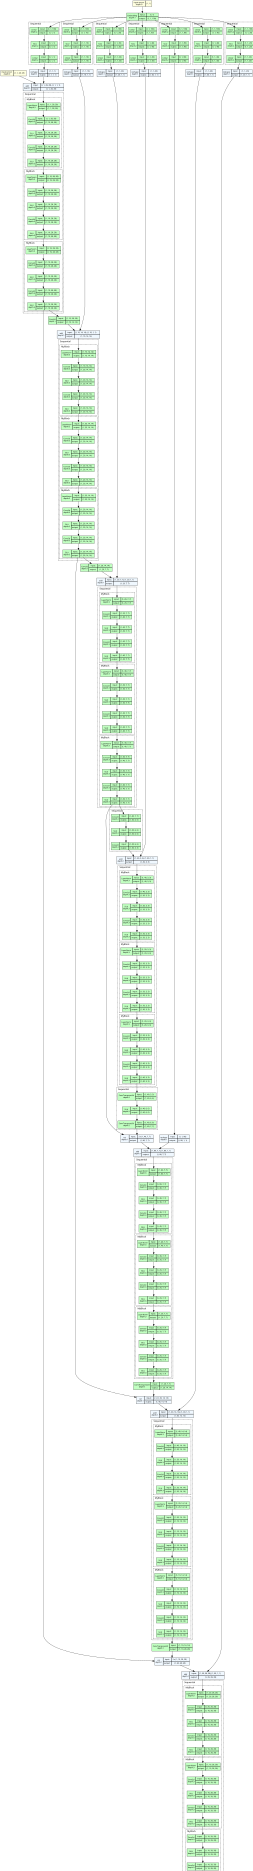

In [21]:
unet = MyUNet(n_steps=1000)

model_graph = draw_graph(
    unet,
    input_data=[
        torch.randn(1, 1, 28, 28),          # x
        torch.zeros(1, 1, dtype=torch.long)  # t
    ],
    device='meta',
    expand_nested=True,   # déroule les sous-modules (MyBlock, etc.)
    show_shapes=True,     # affiche les dimensions des tenseurs
    depth=3               # profondeur du graphe (ajuste selon le détail voulu)
)
model_graph.resize_graph(0.2)
model_graph.visual_graph

# Foward Process
On veut ici voir les couche de bruit successivement ajouté au images d'origines

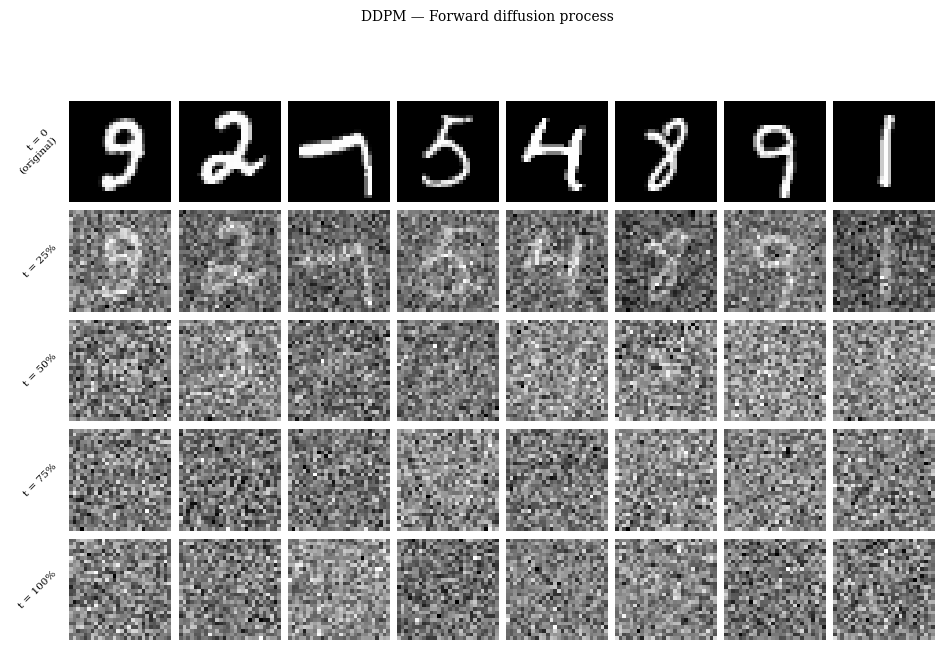

In [12]:
# Defining model
n_steps, min_beta, max_beta = 1000, 10 ** -4, 0.02  # Originally used by the authors
ddpm = MyDDPM(MyUNet(n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)
viz.show_forward(ddpm, loader, device)

Si dessous c'est un demonstrateur pour montrer qu'avec des poids aleatoire la sortie du modele est elle aussi aleatoire.

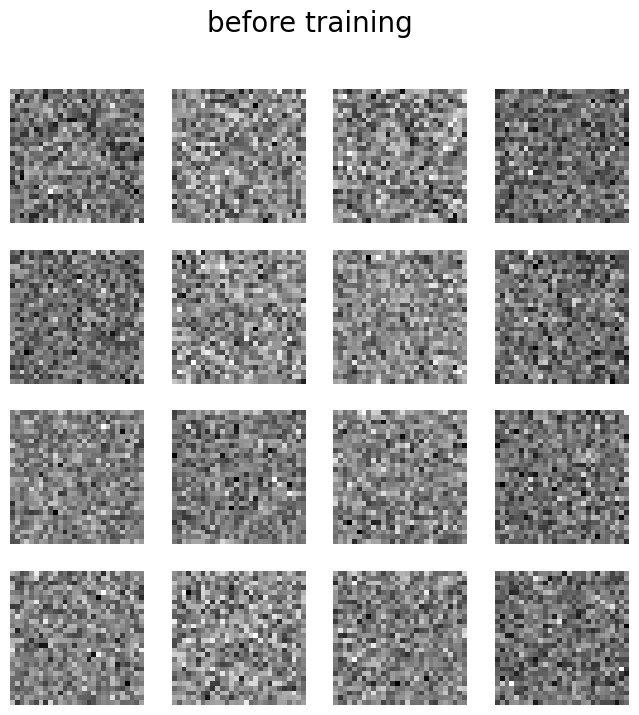

In [13]:
generate = generate_new_images(ddpm)
viz.show_images(generate, "before training")

# Training

In [14]:
def training_loop(ddpm, loader, n_epochs, optim, device, display=False, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    loss_list = []
    n_steps = ddpm.n_steps

    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{n_epochs}", colour="#005500")):
            # Loading data
            x0 = batch[0].to(device)
            n = len(x0)

            # Picking some noise for each of the images in the batch, a timestep and the respective alpha_bars
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)

            # Computing the noisy image based on x0 and the time-step (forward process)
            noisy_imgs = ddpm(x0, t, eta)

            # Getting model estimation of noise based on the images and the time-step
            eta_theta = ddpm.backward(noisy_imgs, t.reshape(n, -1))

            # Optimizing the MSE between the noise plugged and the predicted noise
            loss = mse(eta_theta, eta)
            loss_list.append(loss)
            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)

        # Display images generated at this epoch
        if display:
            viz.show_images(generate_new_images(ddpm, device=device), f"Images generated at epoch {epoch + 1}")

        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.3f}"

        # Storing the model
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model ever (stored)"

        print(log_string)
    
    return loss_list

In [ ]:
# Entraînement
optimizer = Adam(ddpm.parameters(), lr=lr)

loss = training_loop(ddpm, loader, n_epochs, optimizer, device, store_path=store_path)

# Chargement du meilleur modèle sauvegardé
best_model = MyDDPM(MyUNet(n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()

MyDDPM(
  (network): MyUNet(
    (time_embed): Embedding(1000, 100)
    (te1): Sequential(
      (0): Linear(in_features=100, out_features=1, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1, out_features=1, bias=True)
    )
    (b1): Sequential(
      (0): MyBlock(
        (ln): LayerNorm((1, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (1): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (2): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(10, 10, kernel_size=(3, 3), str

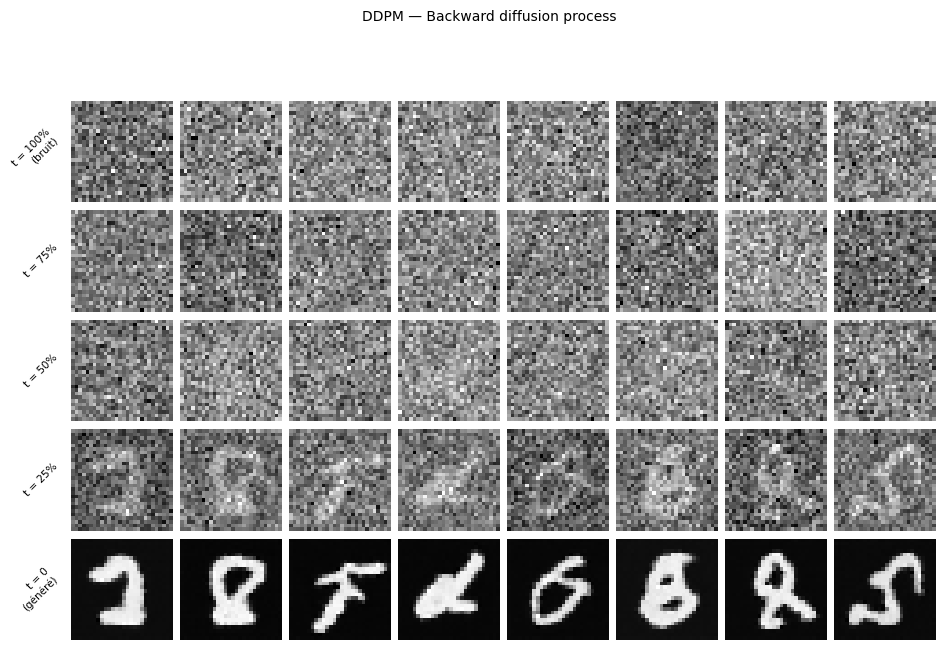

In [16]:
viz.show_backward(best_model, device)